# 04. Preprocesamiento del dataset APTOS 2019

Este notebook define y valida el procedimiento de preprocesamiento común
que será utilizado por las arquitecturas candidatas para la clasificación
de Retinopatía Diabética.

El objetivo principal es reducir las variaciones geométricas no
informativas identificadas durante la exploración visual, preservando
la mayor cantidad posible de información retinal.

El procedimiento se aplicará de manera idéntica a las imágenes utilizadas
por ResNet50 y EfficientNetB3+SE.

En esta etapa se evalúan las transformaciones geométricas y no se realiza
aumento de datos.

## 2. Configuración del entorno, parámetros y carga de particiones

Definición de librerías, rutas del proyecto, resolución espacial objetivo (384 × 384) y carga de las 3487 retinografías registradas en el archivo maestro de particiones experimentales.

In [1]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path(
    "/mnt/c/Users/SeuNg720/Documents/TP1-RetiScan"
)
APTOS_ROOT = (
    PROJECT_ROOT
    / "datasets"
    / "RD"
    / "aptos2019"
)
RAW_DIR = (
    APTOS_ROOT
    / "raw"
)
TRAIN_IMAGES_DIR = (
    RAW_DIR
    / "train_images"
)
METADATA_DIR = (
    APTOS_ROOT
    / "metadata"
)
SPLITS_PATH = (
    METADATA_DIR
    / "aptos2019_splits.csv"
)

splits_df = pd.read_csv(
    SPLITS_PATH
)
IMAGE_SIZE = 384

print(
    "Imágenes:",
    len(splits_df)
)
print(
    "Tamaño objetivo:",
    IMAGE_SIZE,
    "x",
    IMAGE_SIZE
)

Imágenes: 3487
Tamaño objetivo: 384 x 384


## 3. Detección y estandarización del campo retinal

El preprocesamiento geométrico busca reducir las regiones negras no
informativas y estandarizar el tamaño de entrada sin deformar la
geometría de la retina.

El procedimiento propuesto consta de:

1. conversión temporal a escala de grises para detectar el campo retinal;
2. generación de una máscara mediante umbral de intensidad;
3. cierre morfológico para reducir discontinuidades;
4. selección de la región conectada principal;
5. construcción de una envolvente convexa;
6. obtención del bounding box del campo retinal;
7. incorporación de un margen del 2 %;
8. recorte de la región retinal;
9. padding negro para obtener una imagen cuadrada;
10. redimensionamiento a 384 × 384 píxeles.

La imagen RGB original se conserva durante todo el procedimiento; la
escala de grises se utiliza únicamente para estimar la máscara.

In [2]:
def preprocess_retinal_fov(
    image_path,
    output_size=384,
    threshold=10,
    margin_ratio=0.02,
    morph_kernel_size=15
):
    # Leer imagen
    image_bgr = cv2.imread(
        str(image_path),
        cv2.IMREAD_COLOR
    )
    if image_bgr is None:
        raise ValueError(
            f"No se pudo leer la imagen: {image_path}"
        )
    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )
    gray = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2GRAY
    )
    # Máscara inicial de regiones no negras
    binary_mask = (
        gray > threshold
    ).astype(np.uint8) * 255

    # Cierre morfológico
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (
            morph_kernel_size,
            morph_kernel_size
        )
    )
    morph_mask = cv2.morphologyEx(
        binary_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    # Selección de la región conectada principal
    num_labels, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            morph_mask,
            connectivity=8
        )
    )
    h_img, w_img = image_rgb.shape[:2]
    if num_labels <= 1:
        mask = morph_mask
        x, y, w, h = 0, 0, w_img, h_img
    else:
        areas = stats[
            1:,
            cv2.CC_STAT_AREA
        ]
        largest_component = (
            1 + np.argmax(areas)
        )
        component_mask = (
            labels == largest_component
        ).astype(np.uint8) * 255

        # Construcción de la envolvente convexa
        contours, _ = cv2.findContours(
            component_mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )
        if len(contours) == 0:
            mask = component_mask
            x, y, w, h = 0, 0, w_img, h_img
        else:
            largest_contour = max(
                contours,
                key=cv2.contourArea
            )
            hull = cv2.convexHull(
                largest_contour
            )
            mask = np.zeros_like(
                component_mask
            )
            cv2.fillConvexPoly(
                mask,
                hull,
                255
            )
            x, y, w, h = cv2.boundingRect(
                hull
            )

    # Incorporación de un margen del 2 %
    margin_x = int(w * margin_ratio)
    margin_y = int(h * margin_ratio)
    x1 = max(0, x - margin_x)
    y1 = max(0, y - margin_y)
    x2 = min(w_img, x + w + margin_x)
    y2 = min(h_img, y + h + margin_y)

    # Recorte de la región retinal
    masked_rgb = cv2.bitwise_and(
        image_rgb,
        image_rgb,
        mask=mask
    )
    crop = masked_rgb[
        y1:y2,
        x1:x2
    ]

    # Padding negro para obtener imagen cuadrada
    crop_h, crop_w = crop.shape[:2]
    max_dim = max(crop_h, crop_w)
    padded = np.zeros(
        (max_dim, max_dim, 3),
        dtype=crop.dtype
    )
    y_offset = (max_dim - crop_h) // 2
    x_offset = (max_dim - crop_w) // 2
    padded[
        y_offset:y_offset + crop_h,
        x_offset:x_offset + crop_w
    ] = crop

    # Redimensionamiento sin deformación a resolución objetivo
    processed = cv2.resize(
        padded,
        (output_size, output_size),
        interpolation=cv2.INTER_AREA
    )

    metadata = {
        "original_shape": image_rgb.shape,
        "bbox": (x1, y1, x2, y2),
        "crop_shape": crop.shape,
        "padded_shape": padded.shape,
        "final_shape": processed.shape
    }

    return (
        image_rgb,
        mask,
        crop,
        processed,
        metadata
    )

### 3.1. Prueba preliminar sobre una sola muestra

Validación del pipeline de preprocesamiento sobre una retinografía individual de Train para constatar que las dimensiones intermedias y la resolución final de 384 × 384 × 3 sean correctas.

In [3]:
sample_row = (
    splits_df
    .sample(
        n=1,
        random_state=42
    )
    .iloc[0]
)
sample_path = (
    APTOS_ROOT
    / sample_row["image_path"]
)

(
    original,
    mask,
    crop,
    processed,
    metadata
) = preprocess_retinal_fov(
    sample_path,
    output_size=IMAGE_SIZE
)

print(
    "ID:",
    sample_row["id_code"]
)
print(
    "Clase:",
    sample_row["diagnosis"]
)
print(
    "Metadata:"
)
print(
    metadata
)
print(
    "Forma final:",
    processed.shape
)

ID: 0da321efbce6
Clase: 0
Metadata:
{'original_shape': (614, 819, 3), 'bbox': (15, 0, 804, 614), 'crop_shape': (614, 789, 3), 'padded_shape': (789, 789, 3), 'final_shape': (384, 384, 3)}
Forma final: (384, 384, 3)


### 3.2. Visualización de las cuatro etapas del pipeline

Inspección gráfica secuencial que compara la imagen original, la máscara estimada del campo retinal, el recorte con margen y el resultado final normalizado a 384 × 384 píxeles.

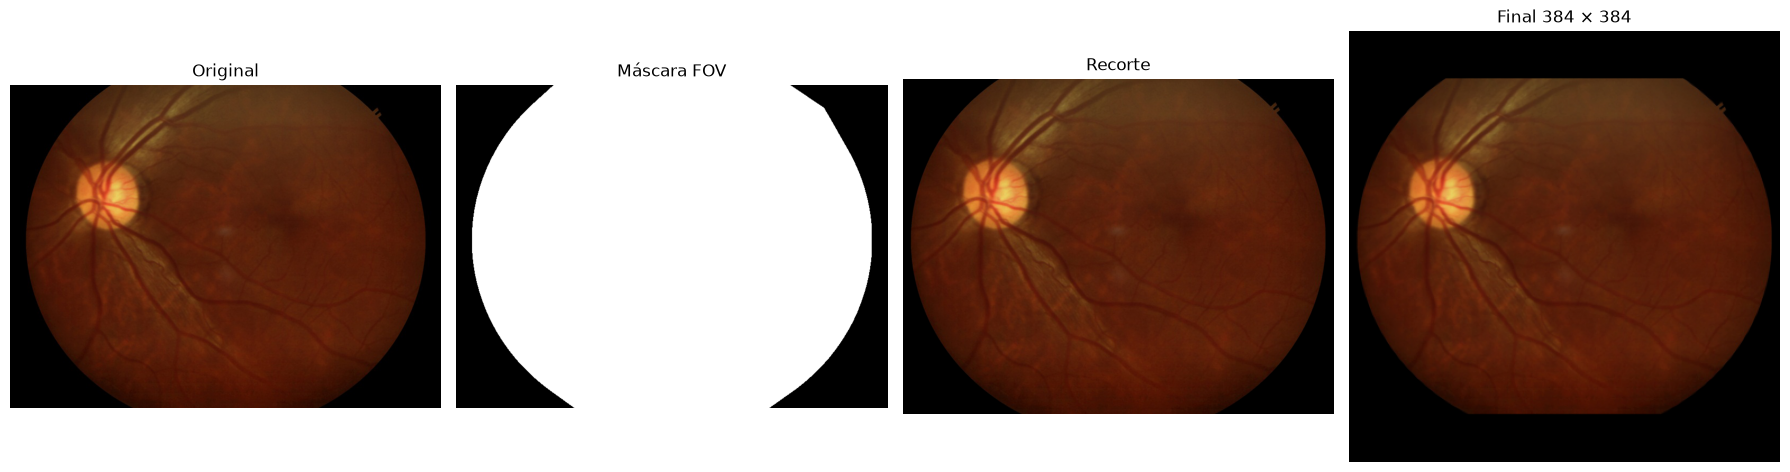

In [4]:
fig, axes = plt.subplots(
    1,
    4,
    figsize=(18, 5)
)

axes[0].imshow(
    original
)
axes[0].set_title(
    "Original"
)
axes[0].axis("off")

axes[1].imshow(
    mask,
    cmap="gray"
)
axes[1].set_title(
    "Máscara FOV"
)
axes[1].axis("off")

axes[2].imshow(
    crop
)
axes[2].set_title(
    "Recorte"
)
axes[2].axis("off")

axes[3].imshow(
    processed
)
axes[3].set_title(
    "Final 384 × 384"
)
axes[3].axis("off")

plt.tight_layout()
plt.show()

### 3.3. Validación del preprocesamiento sobre casos visuales extremos

Antes de aplicar el procedimiento al conjunto completo, se inspeccionan
imágenes previamente identificadas como casos extremos de iluminación o
proporción de fondo negro.

Esta validación busca comprobar que la detección del campo retinal sea
robusta frente a variaciones de exposición, tamaño del campo visual y
encuadre.

In [5]:
extreme_ids = [
    # Baja luminosidad
    "77baa08a1345",
    "b6304c545f95",
    "4a7dc013e802",
    # Alta proporción de fondo negro
    "d4583e9525dc",
    "7269a1d84a57",
    "87d46b1cc4e9",
    "0d8f60ed9280"
]

extreme_df = (
    splits_df[
        splits_df["id_code"].isin(
            extreme_ids
        )
    ]
    .copy()
)

display(
    extreme_df[
        [
            "id_code",
            "diagnosis",
            "experimental_split"
        ]
    ]
)

,id_code,diagnosis,experimental_split
176,0d8f60ed9280,0,validation
1005,4a7dc013e802,4,test
1566,7269a1d84a57,0,train
1636,77baa08a1345,2,train
1863,87d46b1cc4e9,0,train
2518,b6304c545f95,2,test
2923,d4583e9525dc,0,train


### 3.3.1. Inspección comparativa: Original vs. Máscara vs. Resultado final

Visualización tripartita (Original, Máscara FOV y Resultado final a 384 × 384) para cada uno de los casos extremos seleccionados, evaluando la robustez de la máscara y la conservación del campo retinal.

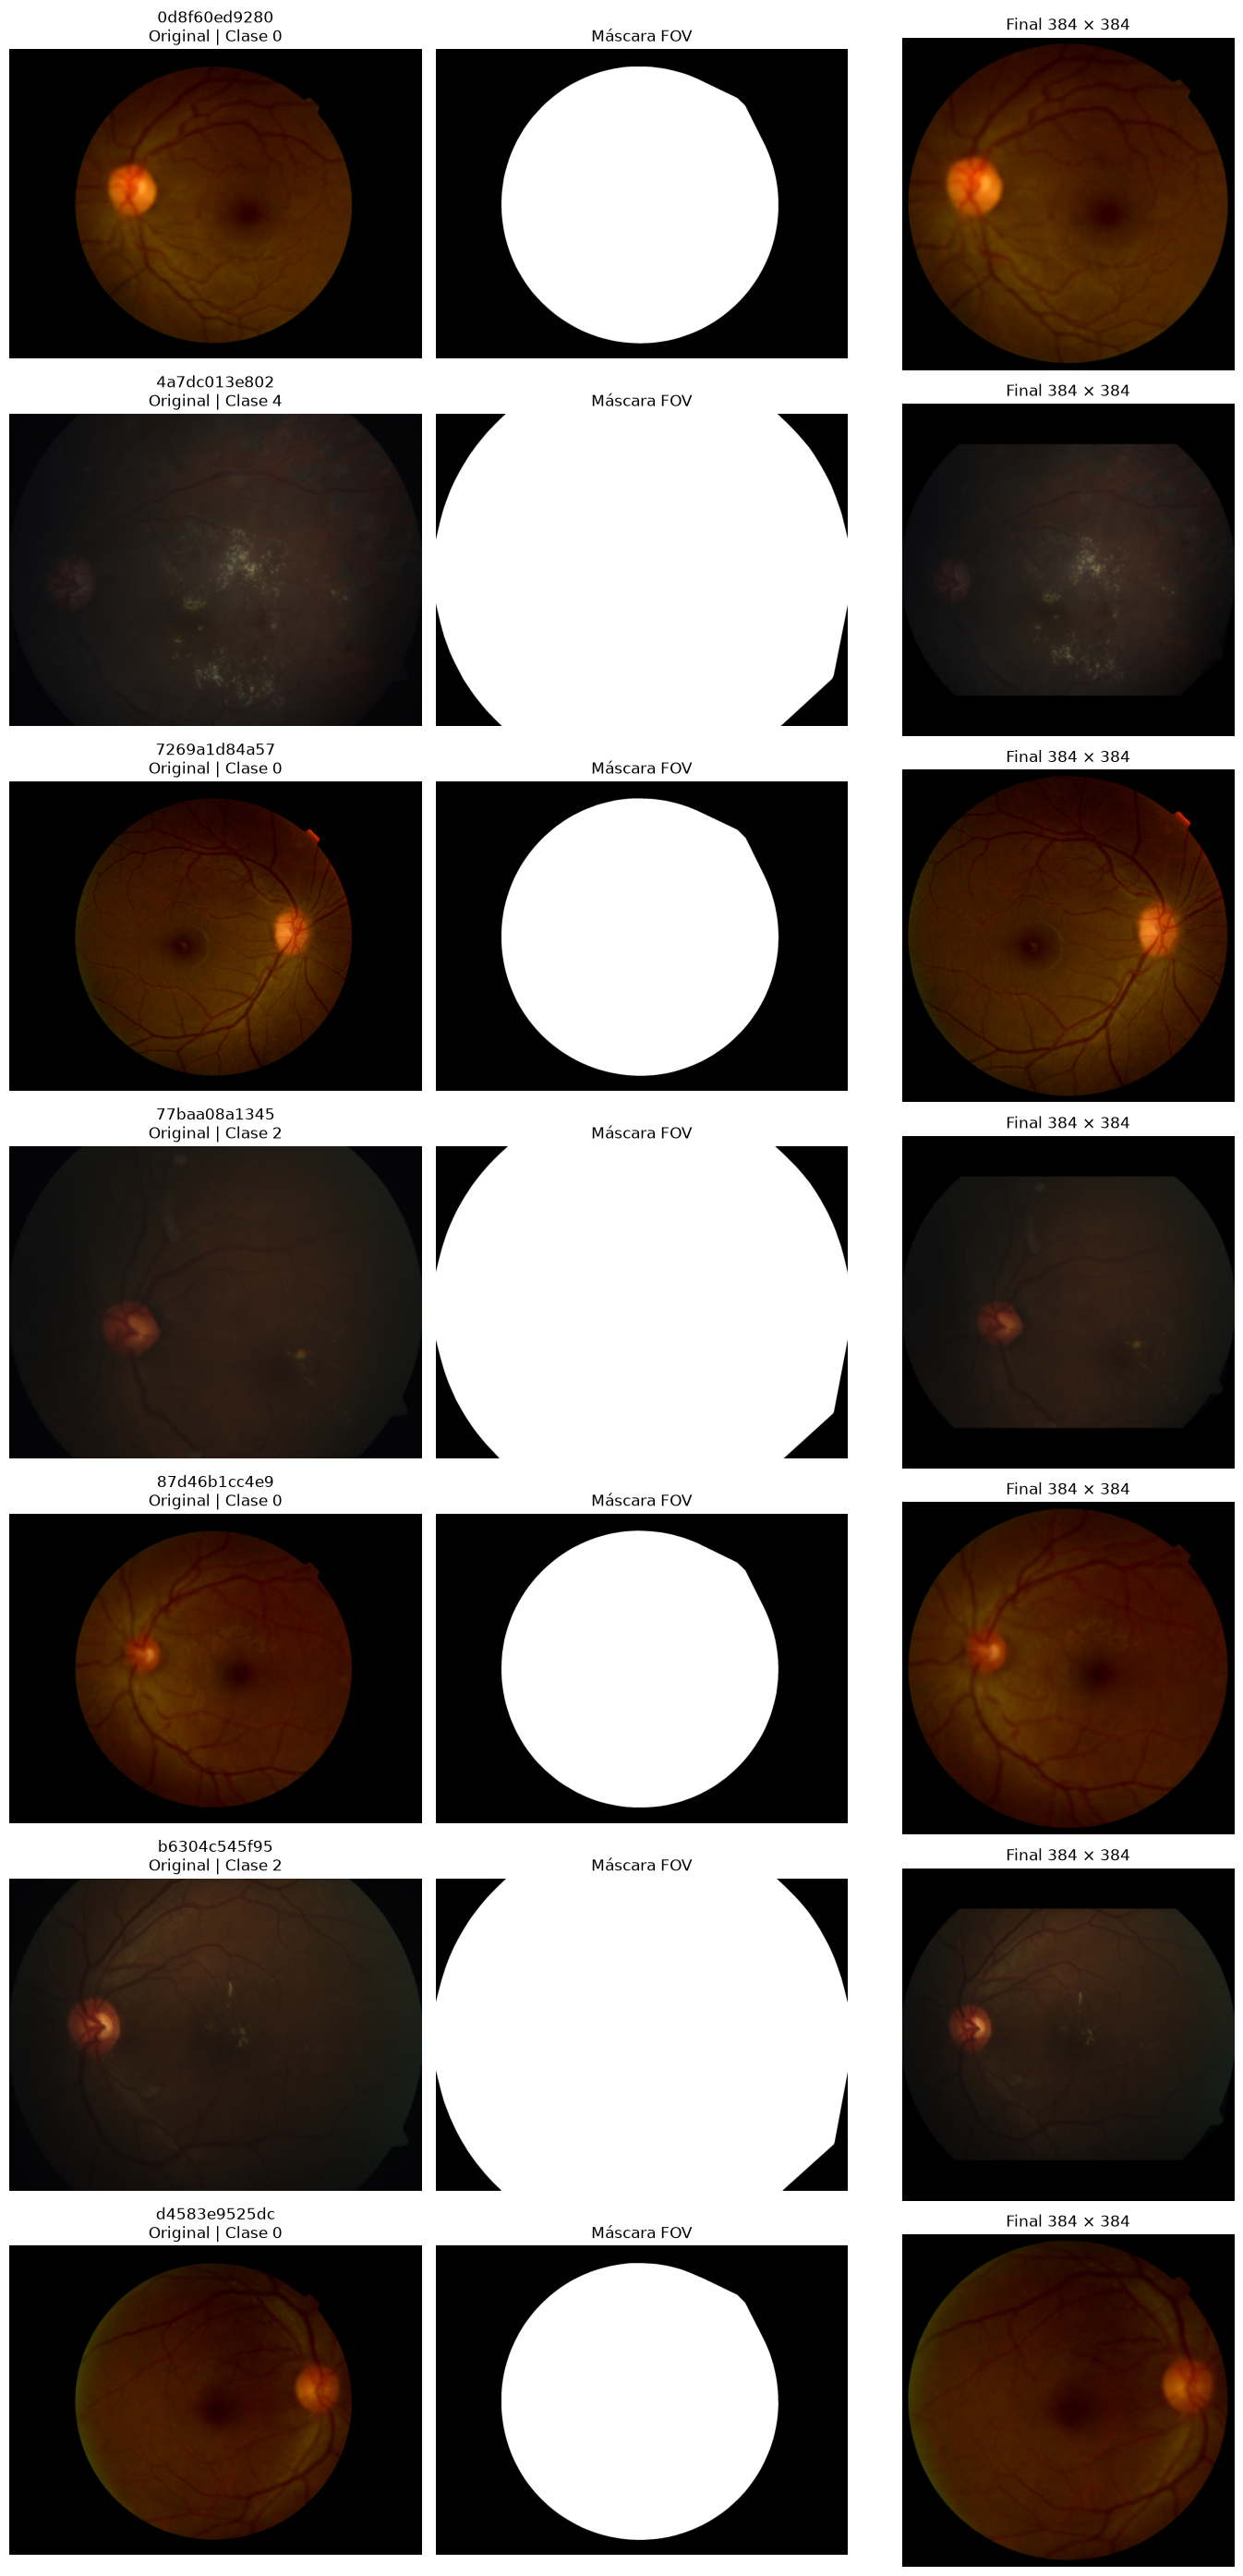

In [6]:
n_cases = len(extreme_df)

fig, axes = plt.subplots(
    nrows=n_cases,
    ncols=3,
    figsize=(14, 4 * n_cases)
)

for row_index, (_, row) in enumerate(
    extreme_df.iterrows()
):
    image_path = (
        APTOS_ROOT
        / row["image_path"]
    )
    (
        original,
        mask,
        crop,
        processed,
        metadata
    ) = preprocess_retinal_fov(
        image_path,
        output_size=IMAGE_SIZE
    )
    axes[row_index, 0].imshow(
        original
    )
    axes[row_index, 0].set_title(
        f"{row['id_code']}\n"
        f"Original | Clase {row['diagnosis']}"
    )
    axes[row_index, 1].imshow(
        mask,
        cmap="gray"
    )
    axes[row_index, 1].set_title(
        "Máscara FOV"
    )
    axes[row_index, 2].imshow(
        processed
    )
    axes[row_index, 2].set_title(
        "Final 384 × 384"
    )
    for col in range(3):
        axes[
            row_index,
            col
        ].axis("off")

plt.tight_layout()
plt.show()

### 3.4. Auditoría del preprocesamiento sobre el conjunto completo

Una vez validado visualmente el procedimiento sobre imágenes
representativas y casos extremos, se aplica temporalmente a las 3487
retinografías del conjunto depurado.

En esta etapa no se guardan las imágenes preprocesadas. El objetivo es
comprobar que todas las imágenes puedan procesarse correctamente y
caracterizar el comportamiento geométrico de la detección del campo
retinal antes de congelar el procedimiento definitivo.

In [7]:
preprocessing_audit_rows = []
preprocessing_failures = []

for i, (_, row) in enumerate(
    splits_df.iterrows()
):
    try:
        image_path = (
            APTOS_ROOT
            / row["image_path"]
        )
        (
            original,
            mask,
            crop,
            processed,
            metadata
        ) = preprocess_retinal_fov(
            image_path,
            output_size=IMAGE_SIZE
        )

        fov_fraction = float(
            (mask > 0).mean()
        )
        crop_area = (
            crop.shape[0]
            * crop.shape[1]
        )
        orig_area = (
            original.shape[0]
            * original.shape[1]
        )
        crop_area_ratio = float(
            crop_area
            / orig_area
        )

        preprocessing_audit_rows.append(
            {
                "id_code":
                    row["id_code"],
                "diagnosis":
                    int(row["diagnosis"]),
                "experimental_split":
                    row["experimental_split"],
                "fov_fraction":
                    fov_fraction,
                "crop_area_ratio":
                    crop_area_ratio,
                "final_height":
                    processed.shape[0],
                "final_width":
                    processed.shape[1],
                "final_channels":
                    processed.shape[2]
            }
        )
    except Exception as e:
        preprocessing_failures.append(
            {
                "id_code":
                    row["id_code"],
                "error":
                    str(e)
            }
        )

    processed_count = (
        i + 1
    )
    if (
        processed_count % 500 == 0
        or
        processed_count == len(splits_df)
    ):
        print(
            f"Procesadas: "
            f"{processed_count}/"
            f"{len(splits_df)}"
        )

preprocessing_audit_df = pd.DataFrame(
    preprocessing_audit_rows
)
preprocessing_failures_df = pd.DataFrame(
    preprocessing_failures
)

Procesadas: 500/3487
Procesadas: 1000/3487
Procesadas: 1500/3487
Procesadas: 2000/3487
Procesadas: 2500/3487
Procesadas: 3000/3487
Procesadas: 3487/3487


### 3.4.1. Verificación de robustez y dimensiones de salida

Comprobación de la cantidad de ejecuciones exitosas, ausencia total de excepciones y verificación de que el 100 % de las imágenes procesadas alcancen las dimensiones objetivo de 384 × 384 × 3.

In [8]:
print(
    "Procesadas correctamente:",
    len(preprocessing_audit_df)
)
print(
    "Fallos:",
    len(preprocessing_failures_df)
)
print(
    "Salidas 384x384:",
    int(
        (
            (
                preprocessing_audit_df[
                    "final_height"
                ] == 384
            )
            &
            (
                preprocessing_audit_df[
                    "final_width"
                ] == 384
            )
            &
            (
                preprocessing_audit_df[
                    "final_channels"
                ] == 3
            )
        ).sum()
    )
)

Procesadas correctamente: 3487
Fallos: 0
Salidas 384x384: 3487


### 3.5. Comportamiento geométrico global

Análisis estadístico descriptivo de la fracción de campo retinal detectada (`fov_fraction`) y del ratio de área conservada tras el recorte (`crop_area_ratio`).

In [9]:
display(
    preprocessing_audit_df[
        [
            "fov_fraction",
            "crop_area_ratio"
        ]
    ]
    .describe()
    .round(4)
)

,fov_fraction,crop_area_ratio
count,3487.0000,3487.0000
mean,0.7711,0.9183
std,0.1379,0.1201
min,0.4738,0.6487
25%,0.7482,0.8759
50%,0.8022,0.9714
75%,0.8360,1.0000
max,1.0000,1.0000


### 3.5.1. Detección de casos extremos en las métricas geométricas

Identificación de las observaciones con menor y mayor cobertura de campo retinal y de aquellas con mayor reducción de área, para comprobar la coherencia anatómica sin alterar el conjunto depurado.

In [10]:
print(
    "Menor proporción de FOV:"
)
display(
    preprocessing_audit_df
    .nsmallest(
        10,
        "fov_fraction"
    )
)
print(
    "\nMayor proporción de FOV:"
)
display(
    preprocessing_audit_df
    .nlargest(
        10,
        "fov_fraction"
    )
)
print(
    "\nMenor área conservada por el recorte:"
)
display(
    preprocessing_audit_df
    .nsmallest(
        10,
        "crop_area_ratio"
    )
)

Menor proporción de FOV:


,id_code,diagnosis,experimental_split,fov_fraction,crop_area_ratio,final_height,final_width,final_channels
1863,87d46b1cc4e9,0,train,0.473763,0.648693,384,384,3
1488,6cb96a6fb029,0,train,0.473879,0.648693,384,384,3
176,0d8f60ed9280,0,validation,0.473983,0.648693,384,384,3
2923,d4583e9525dc,0,train,0.474099,0.648693,384,384,3
3396,f819c65b803c,0,train,0.474292,0.649147,384,384,3
1661,79ade634c633,0,train,0.474392,0.649147,384,384,3
3048,de2eb5c8aa83,0,train,0.474429,0.649147,384,384,3
3163,e5f332efcbc7,0,validation,0.474449,0.649147,384,384,3
1407,66460ecab347,0,train,0.474458,0.649602,384,384,3
152,0b3efe669365,0,train,0.474470,0.649147,384,384,3



Mayor proporción de FOV:


,id_code,diagnosis,experimental_split,fov_fraction,crop_area_ratio,final_height,final_width,final_channels
113,08c17a2d95b7,2,train,1.0,1.0,384,384,3
124,09662e462531,0,train,1.0,1.0,384,384,3
246,12b57dac703e,0,train,1.0,1.0,384,384,3
466,2209daf71aab,0,train,1.0,1.0,384,384,3
467,2221cf5c7935,0,train,1.0,1.0,384,384,3
518,25dc1b41ed9c,2,train,1.0,1.0,384,384,3
707,3461dc601cc2,1,train,1.0,1.0,384,384,3
919,44855f666225,2,train,1.0,1.0,384,384,3
1474,6bcce181be65,0,test,1.0,1.0,384,384,3
1493,6cee2e148520,0,train,1.0,1.0,384,384,3



Menor área conservada por el recorte:


,id_code,diagnosis,experimental_split,fov_fraction,crop_area_ratio,final_height,final_width,final_channels
176,0d8f60ed9280,0,validation,0.473983,0.648693,384,384,3
1488,6cb96a6fb029,0,train,0.473879,0.648693,384,384,3
1863,87d46b1cc4e9,0,train,0.473763,0.648693,384,384,3
2923,d4583e9525dc,0,train,0.474099,0.648693,384,384,3
152,0b3efe669365,0,train,0.474470,0.649147,384,384,3
1661,79ade634c633,0,train,0.474392,0.649147,384,384,3
2926,d4bc001f7224,0,train,0.474569,0.649147,384,384,3
3048,de2eb5c8aa83,0,train,0.474429,0.649147,384,384,3
3163,e5f332efcbc7,0,validation,0.474449,0.649147,384,384,3
3396,f819c65b803c,0,train,0.474292,0.649147,384,384,3


### 3.5.2. Persistencia de la auditoría geométrica

Almacenamiento permanente de los resultados de la auditoría y del registro de fallos en el directorio de resultados para garantizar trazabilidad metodológica.

In [11]:
PREPROCESS_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "RD"
    / "preprocessing"
)
PREPROCESS_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)
preprocessing_audit_df.to_csv(
    PREPROCESS_RESULTS_DIR
    / "aptos2019_preprocessing_audit.csv",
    index=False
)
preprocessing_failures_df.to_csv(
    PREPROCESS_RESULTS_DIR
    / "aptos2019_preprocessing_failures.csv",
    index=False
)
print(
    "Resultados de preprocesamiento guardados en:",
    PREPROCESS_RESULTS_DIR
)

Resultados de preprocesamiento guardados en: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/results/RD/preprocessing


### 3.6. Verificación de imágenes con detección completa del campo visual

Se inspeccionan imágenes cuya proporción de campo visual detectado es igual
a 1.0. Estos casos indican que prácticamente toda la imagen fue considerada
región informativa.

La inspección permite confirmar que este comportamiento corresponde a
retinografías sin regiones negras periféricas significativas y no a errores
de segmentación.

In [12]:
full_fov_cases = (
    preprocessing_audit_df[
        preprocessing_audit_df[
            "fov_fraction"
        ] >= 0.999
    ]
    .head(6)
)

display(
    full_fov_cases[
        [
            "id_code",
            "diagnosis",
            "experimental_split",
            "fov_fraction",
            "crop_area_ratio"
        ]
    ]
)

,id_code,diagnosis,experimental_split,fov_fraction,crop_area_ratio
6,0097f532ac9f,0,train,0.999991,1.0
31,02358b47ea89,0,train,0.999952,1.0
69,0551676cc2aa,0,train,0.999463,1.0
72,05b1bb2bdb81,0,validation,0.999854,1.0
102,07f5d7baf907,0,train,0.999987,1.0
111,08b6e3240858,0,train,0.999627,1.0


### 3.6.1. Inspección visual de casos con campo retinal completo

Visualización tripartita (Original, Máscara FOV y Resultado preprocesado) para verificar que las imágenes con FOV completo conserven la totalidad de su campo anatómico sin recortes indebidos.

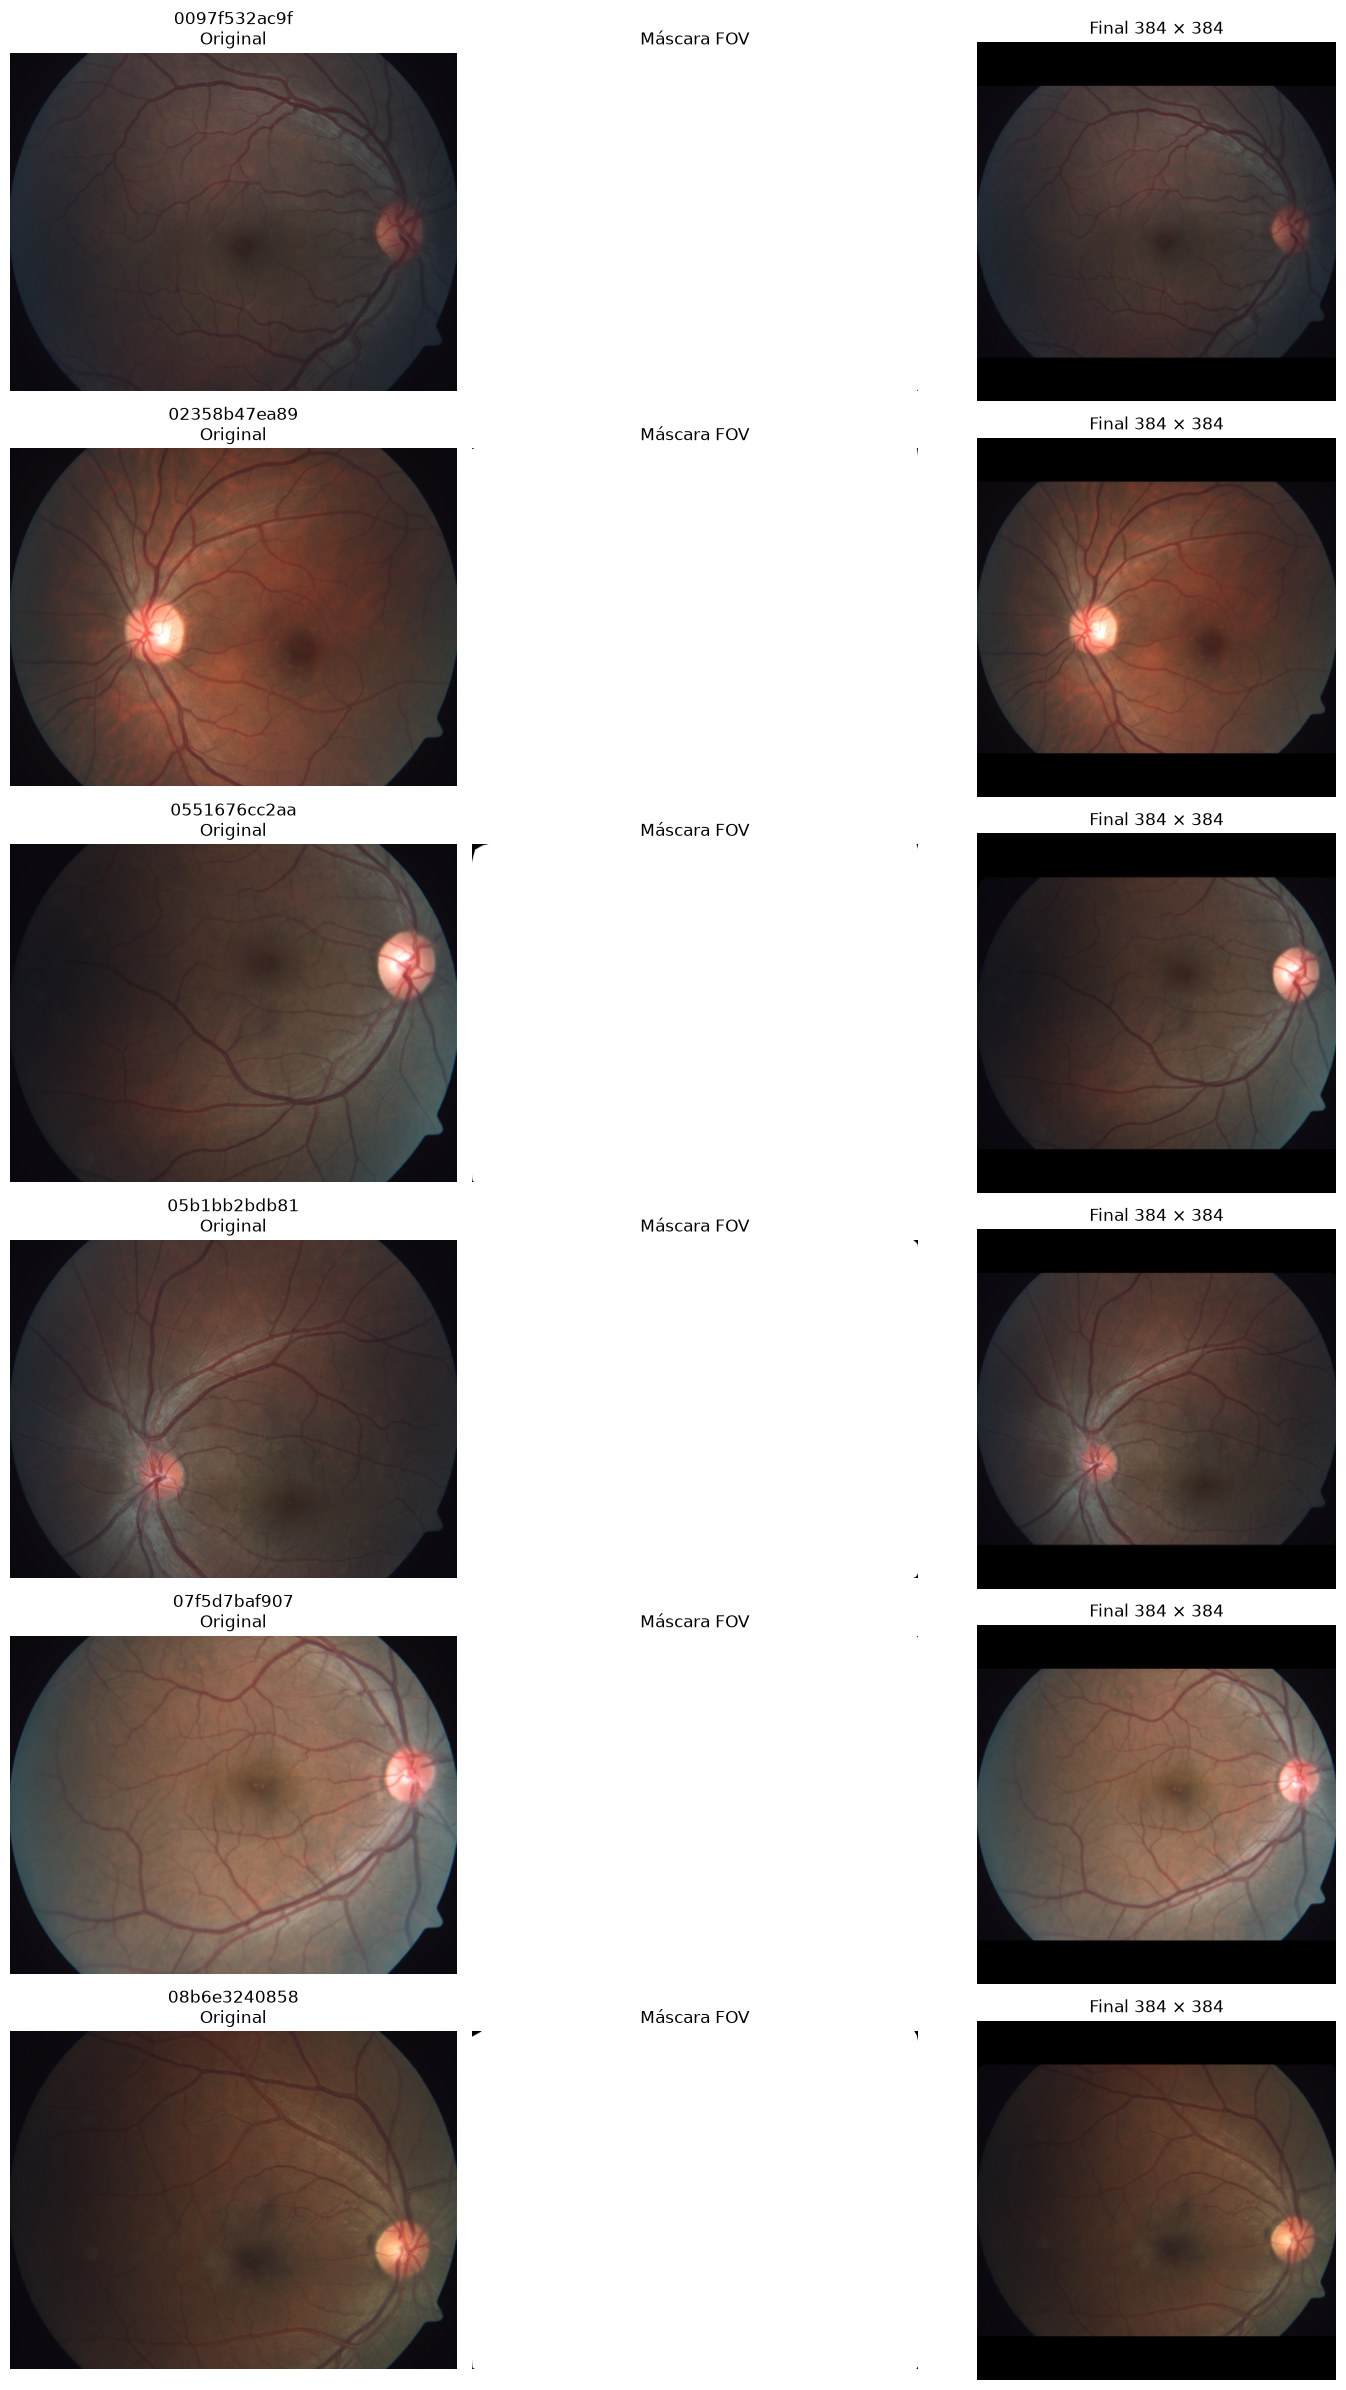

In [13]:
n_cases = len(full_fov_cases)

fig, axes = plt.subplots(
    n_cases,
    3,
    figsize=(14, 4 * n_cases)
)

for row_index, (_, audit_row) in enumerate(
    full_fov_cases.iterrows()
):
    source_row = (
        splits_df[
            splits_df["id_code"]
            == audit_row["id_code"]
        ]
        .iloc[0]
    )
    image_path = (
        APTOS_ROOT
        / source_row["image_path"]
    )
    (
        original,
        mask,
        crop,
        processed,
        metadata
    ) = preprocess_retinal_fov(
        image_path,
        output_size=IMAGE_SIZE
    )
    axes[row_index, 0].imshow(original)
    axes[row_index, 0].set_title(
        f"{audit_row['id_code']}\nOriginal"
    )
    axes[row_index, 1].imshow(
        mask,
        cmap="gray"
    )
    axes[row_index, 1].set_title(
        "Máscara FOV"
    )
    axes[row_index, 2].imshow(processed)
    axes[row_index, 2].set_title(
        "Final 384 × 384"
    )
    for col in range(3):
        axes[row_index, col].axis("off")

plt.tight_layout()
plt.show()

### 3.7. Validación final del procedimiento geométrico

La auditoría global confirmó que las 3487 imágenes del conjunto depurado
pueden ser procesadas correctamente mediante el procedimiento geométrico
propuesto.

No se registraron fallos de detección y todas las imágenes produjeron una
salida RGB de 384 × 384 píxeles.

Los casos con una proporción de FOV cercana a 1.0 fueron inspeccionados
visualmente y corresponden a retinografías en las que el campo retinal
ocupa prácticamente todo el encuadre. En estos casos, conservar la imagen
completa resulta coherente y no representa un error de segmentación.

Por tanto, se congela el siguiente procedimiento común:

1. detección del campo retinal mediante umbral de intensidad;
2. cierre morfológico;
3. selección del contorno principal;
4. envolvente convexa;
5. margen adicional del 2 %;
6. recorte del campo retinal;
7. padding negro cuadrado;
8. redimensionamiento a 384 × 384 mediante interpolación `INTER_AREA`.

Este procedimiento será aplicado de forma idéntica a las imágenes
utilizadas por ambas arquitecturas candidatas.

## 4. Generación del dataset preprocesado

Una vez validado el procedimiento sobre el conjunto completo, se generan
las imágenes preprocesadas correspondientes a las particiones congeladas
Train, Validation y Test.

Las imágenes originales permanecen intactas dentro de `raw/`. No se
aplica aumento de datos durante esta etapa.

In [14]:
PROCESSED_ROOT = (
    APTOS_ROOT
    / "processed"
    / "geometric_384"
)
for split_name in [
    "train",
    "validation",
    "test"
]:
    (
        PROCESSED_ROOT
        / split_name
    ).mkdir(
        parents=True,
        exist_ok=True
    )
print(
    "Destino:",
    PROCESSED_ROOT
)

Destino: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/datasets/RD/aptos2019/processed/geometric_384


### 4.0.1. Generación y almacenamiento físico de las 3487 retinografías preprocesadas

Procesamiento secuencial de las imágenes de Train, Validation y Test aplicando el pipeline geométrico y guardando los archivos resultantes en formato PNG de 384 × 384 píxeles.

In [15]:
processed_rows = []
processing_failures = []

for i, (_, row) in enumerate(
    splits_df.iterrows()
):
    try:
        split_name = row[
            "experimental_split"
        ]
        image_path = (
            APTOS_ROOT
            / row["image_path"]
        )
        output_path = (
            PROCESSED_ROOT
            / split_name
            / f"{row['id_code']}.png"
        )
        (
            _,
            _,
            _,
            processed,
            _
        ) = preprocess_retinal_fov(
            image_path,
            output_size=IMAGE_SIZE
        )
        processed_bgr = cv2.cvtColor(
            processed,
            cv2.COLOR_RGB2BGR
        )
        success = cv2.imwrite(
            str(output_path),
            processed_bgr
        )
        if not success:
            raise IOError(
                "cv2.imwrite no pudo guardar "
                f"{output_path}"
            )
        processed_rows.append(
            {
                "id_code":
                    row["id_code"],
                "diagnosis":
                    int(row["diagnosis"]),
                "experimental_split":
                    split_name,
                "source_path":
                    row["image_path"],
                "processed_path":
                    str(
                        Path(
                            "processed"
                        )
                        / "geometric_384"
                        / split_name
                        / f"{row['id_code']}.png"
                    )
            }
        )
    except Exception as e:
        processing_failures.append(
            {
                "id_code":
                    row["id_code"],
                "error":
                    str(e)
            }
        )
    processed_count = (
        i + 1
    )
    if (
        processed_count % 500 == 0
        or processed_count == len(splits_df)
    ):
        print(
            f"Procesadas y guardadas: "
            f"{processed_count}/"
            f"{len(splits_df)}"
        )

processed_manifest_df = pd.DataFrame(
    processed_rows
)
generation_failures_df = pd.DataFrame(
    processing_failures
)

Procesadas y guardadas: 500/3487
Procesadas y guardadas: 1000/3487
Procesadas y guardadas: 1500/3487
Procesadas y guardadas: 2000/3487
Procesadas y guardadas: 2500/3487
Procesadas y guardadas: 3000/3487
Procesadas y guardadas: 3487/3487


### 4.0.2. Resumen de generación por partición experimental

Verificación de la cantidad de registros generados y recuento por partición (`train`, `validation` y `test`).

In [16]:
print(
    "Imágenes generadas:",
    len(processed_manifest_df)
)
print(
    "Fallos:",
    len(generation_failures_df)
)
print(
    "\nPor split:"
)
print(
    processed_manifest_df[
        "experimental_split"
    ].value_counts()
)

Imágenes generadas: 3487
Fallos: 0

Por split:
experimental_split
train         2440
test           524
validation     523
Name: count, dtype: int64


### 4.1. Verificación física de archivos generados en disco

Comprobación mediante conteo directo en el sistema de archivos para confirmar la existencia de 2440 imágenes en `train/`, 523 en `validation/` y 524 en `test/`.

In [17]:
physical_counts = {}
for split_name in [
    "train",
    "validation",
    "test"
]:
    count = len(
        list(
            (
                PROCESSED_ROOT
                / split_name
            ).glob(
                "*.png"
            )
        )
    )
    physical_counts[
        split_name
    ] = count

print(
    "Archivos físicos:"
)
for split_name, count in (
    physical_counts.items()
):
    print(
        split_name,
        ":",
        count
    )

Archivos físicos:
train : 2440
validation : 523
test : 524


### 4.1.1. Inspección de integridad y formato en archivos físicos

Lectura de una muestra por partición para comprobar que el archivo persistido corresponda efectivamente a 384 × 384 píxeles en modo RGB.

In [18]:
for split_name in [
    "train",
    "validation",
    "test"
]:
    sample_path = next(
        (
            PROCESSED_ROOT
            / split_name
        ).glob(
            "*.png"
        )
    )
    with Image.open(
        sample_path
    ) as img:
        print(
            split_name,
            "→",
            img.size,
            img.mode
        )

train → (384, 384) RGB
validation → (384, 384) RGB
test → (384, 384) RGB


## 5. Persistencia del manifiesto de preprocesamiento

Se almacena un manifiesto que relaciona cada imagen del conjunto
experimental con su archivo original, su partición y la ubicación de
la versión geométricamente preprocesada.

Este archivo permitirá que los pipelines de entrenamiento posteriores
utilicen exactamente las mismas imágenes sin repetir el preprocesamiento.

In [19]:
PROCESSED_MANIFEST_PATH = (
    METADATA_DIR
    / "aptos2019_processed_manifest.csv"
)
processed_manifest_df.to_csv(
    PROCESSED_MANIFEST_PATH,
    index=False
)
generation_failures_df.to_csv(
    PREPROCESS_RESULTS_DIR
    / "aptos2019_generation_failures.csv",
    index=False
)
print(
    "Manifiesto guardado en:",
    PROCESSED_MANIFEST_PATH
)
print(
    "Registros:",
    len(processed_manifest_df)
)

Manifiesto guardado en: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/datasets/RD/aptos2019/metadata/aptos2019_processed_manifest.csv
Registros: 3487


## 6. Configuración definitiva del preprocesamiento

Se registra la configuración geométrica validada para garantizar que
el procedimiento pueda reproducirse posteriormente bajo las mismas
condiciones.

In [20]:
import json

PREPROCESS_CONFIG_PATH = (
    METADATA_DIR
    / "aptos2019_preprocessing_config.json"
)
preprocessing_config = {
    "dataset": "APTOS 2019",
    "input_images": 3487,
    "output_size": [
        384,
        384
    ],
    "color_mode": "RGB",
    "fov_threshold": 10,
    "morphology": {
        "operation": "closing",
        "kernel": "ellipse",
        "kernel_size": 15
    },
    "region_selection": "largest_external_contour",
    "convex_hull": True,
    "margin_ratio": 0.02,
    "square_padding": True,
    "padding_value": 0,
    "resize_interpolation": "INTER_AREA",
    "data_augmentation": False,
    "train_images": 2440,
    "validation_images": 523,
    "test_images": 524
}

with open(
    PREPROCESS_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        preprocessing_config,
        f,
        indent=4,
        ensure_ascii=False
    )

print(
    "Configuración guardada en:",
    PREPROCESS_CONFIG_PATH
)

Configuración guardada en: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/datasets/RD/aptos2019/metadata/aptos2019_preprocessing_config.json


## 7. Verificación definitiva de integridad

Comprobación mediante aserciones formales para garantizar la consistencia del manifiesto, la ausencia de fallos, la unicidad de los identificadores, la exactitud de los tamaños por partición y la existencia física de las 3487 imágenes preprocesadas en disco.

In [21]:
assert len(
    processed_manifest_df
) == 3487
assert len(
    generation_failures_df
) == 0
assert (
    processed_manifest_df[
        "id_code"
    ].is_unique
)
assert (
    processed_manifest_df[
        "experimental_split"
    ].value_counts()["train"]
) == 2440
assert (
    processed_manifest_df[
        "experimental_split"
    ].value_counts()["validation"]
) == 523
assert (
    processed_manifest_df[
        "experimental_split"
    ].value_counts()["test"]
) == 524

missing_processed = (
    processed_manifest_df[
        "processed_path"
    ]
    .apply(
        lambda x:
            not (
                APTOS_ROOT
                / x
            ).exists()
    )
    .sum()
)
assert missing_processed == 0

print(
    "Todas las verificaciones del "
    "dataset preprocesado fueron superadas."
)

Todas las verificaciones del dataset preprocesado fueron superadas.


## 8. Conclusión

Se definió y validó un procedimiento geométrico común para las 3487
retinografías del conjunto experimental APTOS 2019.

El procedimiento detecta el campo retinal, aplica una envolvente convexa,
incorpora un margen del 2 %, realiza el recorte correspondiente, agrega
padding negro cuadrado y redimensiona la imagen a 384 × 384 píxeles sin
deformar su relación geométrica.

La auditoría sobre el conjunto completo no registró fallos y todas las
imágenes generadas presentan formato RGB de 384 × 384 píxeles.

Las imágenes originales permanecen intactas y las versiones
preprocesadas fueron almacenadas por partición experimental:

- Train: 2440 imágenes.
- Validation: 523 imágenes.
- Test: 524 imágenes.

No se aplicó aumento de datos durante esta etapa. El Data Augmentation
será aplicado dinámicamente únicamente sobre Train durante el
entrenamiento.

Este mismo conjunto preprocesado será utilizado por ResNet50 y
EfficientNetB3+SE para mantener condiciones experimentales comparables.